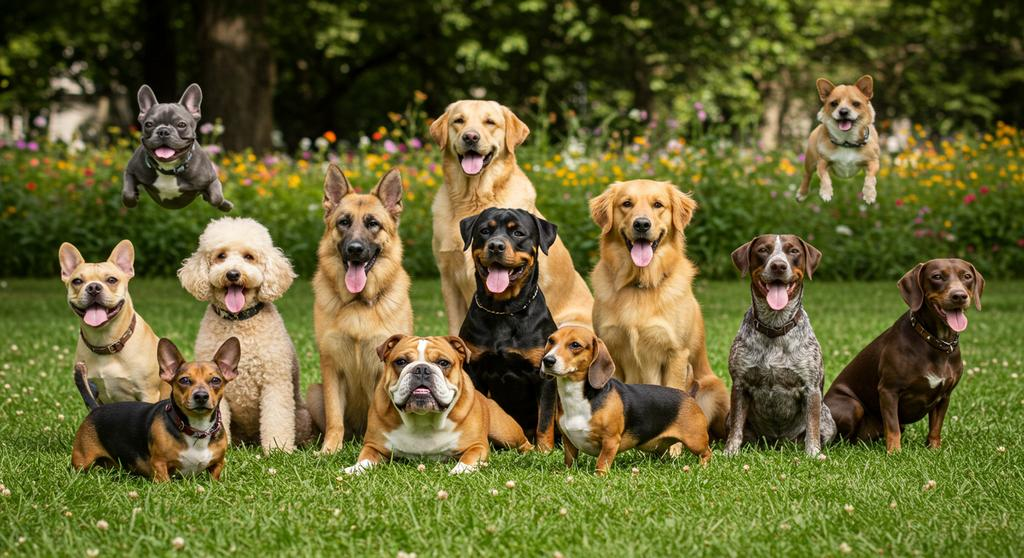

# **Dog Breed Classification: NASnet**

This project focuses on classifying dog breeds using deep learning and transfer learning techniques. The images used for the dataset were obtained through Bing image search and organized by breed.
The goal is to build an image classification system capable of identifying different dog breeds from images. The approach uses pretrained models as feature extractors combined with machine learning classifiers.

### **Dog Breeds Covered**
The dataset contains images from the following dog breeds, each class will contain images representing the corresponding breed, which will be used to train and evaluate the classification models:

- **Pekingese**
- **Husky**
- **Bulldog**
- **Pitbull**
- **Beagle**



### **1) Load Libraries**

This code imports essential libraries for image processing, deep learning, and visualization. Below is a description of each library and its purpose:

- **`numpy`**: Used to handle multidimensional arrays and perform mathematical computations.
- **`matplotlib.pyplot`**: Allows effective visualization of graphs and images.
- **`glob`**: Helps search for files in the system using defined patterns.
- **`cv2` (OpenCV)**: A library used to load, process, and transform images.
- **`os`**: Provides tools to manage system paths and files.
- **`seaborn`**: Facilitates the creation of statistical visualizations.
- **`keras.models`**: Includes two ways to build models: `Sequential`, for linear architectures, and `Model`, for more complex architectures.
- **Keras layers**:
  - **`Dense`**: Adds fully connected layers to the model.
  - **`Flatten`**: Converts multidimensional data into a one-dimensional vector.
  - **`Conv2D`**: Extracts spatial features from images.
  - **`MaxPooling2D`**: Reduces the dimensionality of feature maps by selecting the most important values.
  - **`BatchNormalization`**: Normalizes network activations to accelerate training.
- **`VGG16`**: A widely used pretrained Keras model for transfer learning, where its layers are used as a feature extractor for custom tasks.

Overall, this code sets up a robust environment for developing and evaluating deep learning models for image-related tasks.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import cv2

from keras.models import Model, Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, BatchNormalization
import os
import seaborn as sns
from keras.applications.nasnet import NASNetLarge
from sklearn.model_selection import train_test_split
import numpy as np
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

### **2) Training Data Capture and Processing**

This code loads and processes training images from a specific directory, storing both the images and their corresponding labels in arrays for use in deep learning models.

1. **Initialization**: The lists `train_images` and `train_labels` are created to store the processed images and their class labels.
2. **Directory traversal**: All folders inside the training directory are explored, and the name of each folder is used as the corresponding label (`label`).
3. **Image loading**: Inside each folder, images with the `.jpg` extension are searched for. The images are loaded using `cv2.imread`. If an image cannot be loaded, an error message is printed and the file is skipped.
4. **Image processing**: Each loaded image is resized to a uniform size defined by `SIZE` and converted from BGR format (the default in OpenCV) to RGB, which is the standard format for neural networks.
5. **Storage and conversion**: The processed images are stored in the `train_images` list and their labels in `train_labels`. Finally, both lists are converted into NumPy arrays (`np.array`) to facilitate their use in deep learning models.


#### **2.1) Load Data**

Capture training data and labels into respective lists

In [3]:
SIZE_Nas = 224  #Resize images

According to the documentation, when `include_top=False`, the input image must have three channels and a size of **224 × 224 pixels**, resulting in an input shape of **(224, 224, 3)**. In this format, **224** represents the height, **224** the width, and **3** the number of color channels (RGB).


In [4]:
def load_images_and_labels(base_path, size):
    images = []
    labels = []

    for directory_path in glob.glob(f"{base_path}/*"):
        label = directory_path.split("\\")[-1] 
        print(label)
        for img_path in glob.glob(os.path.join(directory_path, "*.jpg")):
            print(img_path)
            img = cv2.imread(img_path, cv2.IMREAD_COLOR)
            if img is None: 
                print(f"Error loading image: {img_path}")
                continue
            img = cv2.resize(img, (size, size))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            images.append(img)
            labels.append(label)
    images = np.array(images)
    labels = np.array(labels)
    print(f"Loaded {len(images)} images with labels.")
    return images, labels

In [10]:
images_Nas, labels_Nas = load_images_and_labels("images", SIZE_Nas)

beagle
images\beagle\000001.jpg
images\beagle\000002.jpg
images\beagle\000003.jpg
images\beagle\000004.jpg
images\beagle\000005.jpg
images\beagle\000006.jpg
images\beagle\000007.jpg
images\beagle\000008.jpg
images\beagle\000009.jpg
images\beagle\000010.jpg
images\beagle\000011.jpg
images\beagle\000012.jpg
images\beagle\000013.jpg
images\beagle\000014.jpg
images\beagle\000015.jpg
images\beagle\000016.jpg
images\beagle\000017.jpg
images\beagle\000018.jpg
images\beagle\000019.jpg
images\beagle\000020.jpg
images\beagle\000021.jpg
images\beagle\000022.jpg
images\beagle\000023.jpg
images\beagle\000024.jpg
images\beagle\000025.jpg
images\beagle\000026.jpg
images\beagle\000027.jpg
images\beagle\000028.jpg
images\beagle\000029.jpg
images\beagle\000030.jpg
images\beagle\000031.jpg
images\beagle\000032.jpg
images\beagle\000033.jpg
images\beagle\000034.jpg
images\beagle\000035.jpg
images\beagle\000036.jpg
images\beagle\000037.jpg
images\beagle\000038.jpg
images\beagle\000039.jpg
images\beagle\0000

In [14]:
print(f"Shape of images: {images_Nas.shape}")
print(f"Shape of labels: {labels_Nas.shape}")


Shape of images: (214, 224, 224, 3)
Shape of labels: (214,)


In [15]:
labels_Nas[:10]

array(['beagle', 'beagle', 'beagle', 'beagle', 'beagle', 'beagle',
       'beagle', 'beagle', 'beagle', 'beagle'], dtype='<U9')

In [16]:
train_images, temp_images, train_labels, temp_labels = train_test_split(images_Nas, labels_Nas, test_size=0.3, random_state=42)
val_images, test_images, val_labels, test_labels = train_test_split(temp_images, temp_labels, test_size=0.5, random_state=42)

In [17]:
print(f"Shape of images: {images_Nas.shape}")
print(f"Shape of labels: {labels_Nas.shape}")
print (f"Shape of train_images: {train_images.shape}")
print (f"Shape of train_labels: {train_labels.shape}")
print (f"Shape of val_images: {val_images.shape}")
print (f"Shape of val_labels: {val_labels.shape}")
print (f"Shape of test_images: {test_images.shape}")
print (f"Shape of test_labels: {test_labels.shape}")

Shape of images: (214, 224, 224, 3)
Shape of labels: (214,)
Shape of train_images: (149, 224, 224, 3)
Shape of train_labels: (149,)
Shape of val_images: (32, 224, 224, 3)
Shape of val_labels: (32,)
Shape of test_images: (33, 224, 224, 3)
Shape of test_labels: (33,)


###  **Validation Data Capture and Processing**

This code is used to load and process images from a validation dataset. The following explains how it works:

1. **Initialization**:
   - Empty lists `test_images` and `test_labels` are created to store the processed images and their corresponding labels.

2. **Iterating through the validation directory**:
   - Using `glob.glob`, each folder inside the validation directory is traversed.
   - The name of each folder is extracted as the class label (`fruit_label`) using `split("/")`.

3. **Loading and verification of images**:
   - Inside each folder, images with the `.jpg` extension are searched.
   - Each image is loaded using `cv2.imread` in BGR format. If the image does not load correctly (`None`), it is skipped and an error message is printed.

4. **Image processing**:
   - Images are resized to a uniform size specified by `SIZE` (e.g., 224x224 pixels) using `cv2.resize`.
   - The color format of the images is converted from RGB to BGR to be compatible with deep learning models.

5. **Storage and conversion**:
   - Each processed image is stored in `test_images`, and its corresponding label in `test_labels`.
   - Finally, both lists are converted into NumPy arrays (`np.array`) to facilitate their use in deep learning models.

This process ensures that the images from the validation dataset are preprocessed and ready to be used in the evaluation of the model.

In [19]:
test_labels

array(['husky', 'beagle', 'beagle', 'husky', 'husky', 'husky', 'pitbull',
       'pekingese', 'pekingese', 'bulldog', 'bulldog', 'pekingese',
       'pitbull', 'bulldog', 'bulldog', 'husky', 'pitbull', 'beagle',
       'husky', 'bulldog', 'beagle', 'pitbull', 'husky', 'husky',
       'pekingese', 'pitbull', 'beagle', 'pekingese', 'pitbull', 'beagle',
       'pekingese', 'pekingese', 'bulldog'], dtype='<U9')

In [31]:
#Encode labels from text to integers.
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
le.fit(test_labels)
train_labels_encoded = le.transform(train_labels)
le.fit(val_labels)
val_labels_encoded = le.transform(val_labels)
le.fit(test_labels)
test_labels_encoded = le.transform(test_labels)

In [32]:
#Split data into test and train datasets (already split but assigning to meaningful convention)
x_train, y_train, x_val, y_val, x_test, y_test = train_images, train_labels_encoded, val_images, val_labels_encoded, test_images, test_labels_encoded
y_train

array([3, 1, 2, 4, 0, 0, 0, 0, 0, 1, 2, 3, 1, 2, 3, 1, 0, 3, 1, 2, 0, 3,
       2, 2, 0, 1, 0, 3, 2, 1, 1, 3, 0, 4, 1, 0, 3, 2, 0, 0, 4, 4, 0, 0,
       2, 4, 3, 0, 0, 2, 3, 2, 3, 2, 0, 1, 2, 3, 3, 0, 4, 3, 1, 3, 1, 0,
       3, 0, 2, 0, 4, 3, 1, 0, 4, 0, 1, 3, 0, 3, 0, 2, 1, 2, 4, 3, 4, 0,
       1, 0, 0, 2, 1, 1, 4, 4, 1, 0, 0, 1, 4, 2, 0, 3, 1, 4, 2, 4, 4, 1,
       1, 2, 1, 3, 4, 3, 1, 0, 1, 0, 1, 3, 4, 4, 2, 0, 3, 4, 0, 1, 3, 2,
       3, 2, 2, 2, 1, 4, 1, 2, 4, 0, 4, 1, 2, 0, 1, 4, 2])

In [35]:
#One hot encode y values for neural network.
from keras.utils import to_categorical

y_train_one_hot = to_categorical(train_labels_encoded)
y_val_one_hot = to_categorical(val_labels_encoded)
y_test_one_hot = to_categorical(test_labels_encoded)

In [34]:
# Normalize pixel values to between 0 and 1
x_train, x_test = x_train / 255.0, x_test / 255.0

## **NASNet**

NASNet (Neural Architecture Search Network) is a convolutional neural network architecture designed using **Neural Architecture Search (NAS)**, a technique where machine learning algorithms automatically discover optimal neural network structures. Instead of manually designing the architecture, the search process identifies efficient building blocks called **cells**, which are then repeated to create deep networks capable of high performance in image recognition tasks.

Two main versions are commonly used in Keras: **NASNetLarge**, which provides higher accuracy but requires larger input images and more computational resources, and **NASNetMobile**, a smaller and more efficient version designed for mobile or resource-limited environments with a typical input size of 224×224. Both models can load **pretrained ImageNet weights**, making them useful for transfer learning in computer vision applications.

In [44]:
#Load model without classifier/fully connected layers
nas_model = NASNetLarge(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

In [45]:
nas_model.summary()

Model: "NASNet"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 stem_conv1 (Conv2D)         (None, 111, 111, 96)         2592      ['input_3[0][0]']             
                                                                                                  
 stem_bn1 (BatchNormalizati  (None, 111, 111, 96)         384       ['stem_conv1[0][0]']          
 on)                                                                                              
                                                                                                  
 activation_520 (Activation  (None, 111, 111, 96)         0         ['stem_bn1[0][0]']       

## **Freezing Pre-trained Layers**

In this step, all layers of the model are set as non-trainable by assigning `layer.trainable = False`. This freezes the weights of the pre-trained network so that they are not updated during training. Freezing the layers is important when using transfer learning because the model already contains useful features learned from a large dataset (such as ImageNet), and retraining them could unnecessarily modify these learned representations.

After freezing the layers, `model.summary()` shows that the number of trainable parameters is 0, confirming that the base model will remain unchanged during training. This allows the model to use the pre-trained feature extractor while only training any new layers that may be added later for the specific classification task.

In [46]:
#Make loaded layers as non-trainable. This is important as we want to work with pre-trained weights
for layer in nas_model.layers:
	layer.trainable = False

nas_model.summary()  #Trainable parameters will be 0

Model: "NASNet"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_3 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 stem_conv1 (Conv2D)         (None, 111, 111, 96)         2592      ['input_3[0][0]']             
                                                                                                  
 stem_bn1 (BatchNormalizati  (None, 111, 111, 96)         384       ['stem_conv1[0][0]']          
 on)                                                                                              
                                                                                                  
 activation_520 (Activation  (None, 111, 111, 96)         0         ['stem_bn1[0][0]']       

In [53]:
# Train features
X_train_feature = nas_model.predict(x_train)
X_train_features = X_train_feature.reshape(X_train_feature.shape[0], -1)

# Test features
X_test_feature = nas_model.predict(x_test)
X_test_features = X_test_feature.reshape(X_test_feature.shape[0], -1)

2/2 [==============================] - 2s 146ms/step


In [54]:
nn_model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_features.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(len(np.unique(y_train)), activation='softmax')
])

In [55]:
nn_model.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [56]:
nn_model.fit(
    X_train_features,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
4/4 [==============================] - 2s 255ms/step - loss: 1.8670 - accuracy: 0.6555 - val_loss: 1.5912 - val_accuracy: 0.9333
Epoch 2/20
4/4 [==============================] - 1s 194ms/step - loss: 1.1727 - accuracy: 0.9664 - val_loss: 2.0128 - val_accuracy: 0.9333
Epoch 3/20
4/4 [==============================] - 1s 190ms/step - loss: 0.6995 - accuracy: 0.9664 - val_loss: 3.0339 - val_accuracy: 0.9333
Epoch 4/20
4/4 [==============================] - 1s 184ms/step - loss: 2.3809e-06 - accuracy: 1.0000 - val_loss: 3.5473 - val_accuracy: 0.9333
Epoch 5/20
4/4 [==============================] - 1s 178ms/step - loss: 0.2444 - accuracy: 0.9916 - val_loss: 3.3641 - val_accuracy: 0.9667
Epoch 6/20
4/4 [==============================] - 1s 177ms/step - loss: 2.2783e-05 - accuracy: 1.0000 - val_loss: 3.1153 - val_accuracy: 0.9667
Epoch 7/20
4/4 [==============================] - 1s 182ms/step - loss: 0.0733 - accuracy: 0.9916 - val_loss: 3.6906 - val_accuracy: 0.9667
Epoch 8/20
4

In [57]:
y_pred_probs = nn_model.predict(X_test_features)

y_pred = np.argmax(y_pred_probs, axis=1)

2/2 [==============================] - 0s 13ms/step


# **Metrics**

In [67]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
auc = roc_auc_score(y_test_bin, y_pred_probs, average='weighted', multi_class='ovr')

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)
print("AUC:", auc)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)

Accuracy: 0.9696969696969697
Precision: 0.9740259740259739
Recall: 0.9696969696969697
F1-Score: 0.96985236985237
AUC: 1.0
Confusion Matrix:
[[6 0 0 0 0]
 [0 6 0 0 0]
 [0 0 7 0 1]
 [0 0 0 7 0]
 [0 0 0 0 6]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         6
           2       1.00      0.88      0.93         8
           3       1.00      1.00      1.00         7
           4       0.86      1.00      0.92         6

    accuracy                           0.97        33
   macro avg       0.97      0.97      0.97        33
weighted avg       0.97      0.97      0.97        33



<Axes: >

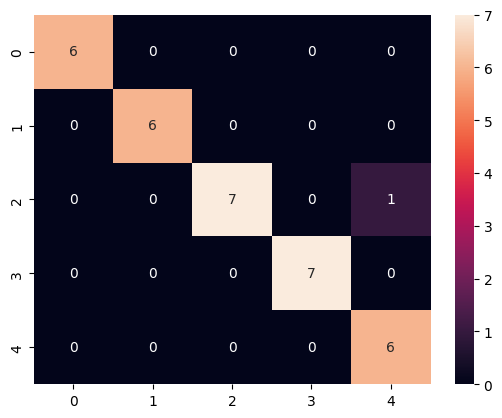

In [61]:
#Confusion Matrix - verify accuracy of each class
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
#print(cm)
sns.heatmap(cm, annot=True)


1/1 [==============================] - 0s 22ms/step
The prediction for this image is: bulldog
The actual label for this image is: bulldog


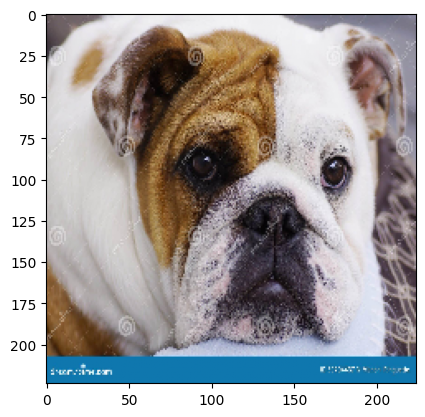

In [64]:
n = np.random.randint(0, x_test.shape[0])
img = x_test[n]
plt.imshow(img)
input_img = np.expand_dims(img, axis=0)

# Extract CNN features
input_img_feature = nas_model.predict(input_img)
input_img_features = input_img_feature.reshape(input_img_feature.shape[0], -1)

# Neural network prediction (probabilities)
prediction_probs = nn_model.predict(input_img_features)
prediction_class = np.argmax(prediction_probs, axis=1)
prediction_label = le.inverse_transform(prediction_class)

print("The prediction for this image is:", prediction_label[0])
print("The actual label for this image is:", test_labels[n])


## **Export Results**

In [72]:
import json

def save_metrics(model_name, configuration, acc, prec, rec, f1):
    save_dir_path = "model_metrics"
    
    metrics_dict = {"model": model_name,
        "configuration": configuration,
        "accuracy": float(acc),
        "precision": float(prec),
        "recall": float(rec),
        "f1_score": float(f1),
    }

    if not os.path.exists(save_dir_path):
        os.makedirs(save_dir_path, exist_ok=True)
    file_path = os.path.join(save_dir_path, f"{model_name}_{configuration}.json")
    with open(file_path, "w") as f: json.dump(metrics_dict, f, indent=4)
    print(f"Metrics saved to: {file_path}")



In [73]:
save_metrics(
    model_name="NASNetLarge_Feature_Extractor",
    configuration="MLP",
    acc=accuracy,
    prec=precision,
    rec=recall,
    f1=f1,
)

Metrics saved to: model_metrics\NASNetLarge_Feature_Extractor_MLP.json
